In [40]:
# Descomprimir el nuevo dataset desde Google Drive
print("\n📦 Descomprimiendo flickr_logos_27_dataset.zip...")
!unzip -q /content/drive/MyDrive/flickr_logos_27_dataset.zip -d /content/dataset/

# Copiar data.yaml desde la carpeta descomprimida si existe, o desde Drive raíz
# Primero, intentamos desde la carpeta descomprimida del dataset
!cp /content/dataset/flickr_logos_27_dataset/data.yaml /content/data.yaml 2>/dev/null || \
!cp /content/drive/MyDrive/data.yaml /content/data.yaml 2>/dev/null || \
 echo "⚠️ data.yaml no encontrado ni en el dataset descomprimido ni en Drive raíz"

# Verificar estructura del nuevo dataset
print("\n📂 Estructura del nuevo dataset (contenido de /content/dataset/flickr_logos_27_dataset/):")
!ls -lh /content/dataset/flickr_logos_27_dataset/

print("\n📊 Imágenes de entrenamiento en el nuevo dataset:")
!ls /content/dataset/flickr_logos_27_dataset/images/train/ | wc -l

print("\n📊 Imágenes de validación en el nuevo dataset:")
!ls /content/dataset/flickr_logos_27_dataset/images/val/ | wc -l


📦 Descomprimiendo flickr_logos_27_dataset.zip...
replace /content/dataset/__MACOSX/._flickr_logos_27_dataset? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/flickr_logos_27_dataset/flickr_logos_27_dataset_query_set_annotation.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/__MACOSX/flickr_logos_27_dataset/._flickr_logos_27_dataset_query_set_annotation.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/__MACOSX/flickr_logos_27_dataset/._flickr_logos_27_dataset_images? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
⚠️ data.yaml no encontrado ni en el dataset descomprimido ni en Drive raíz

📂 Estructura del nuevo dataset (contenido de /content/dataset/flickr_logos_27_dataset/):
total 488K
-rw-rw-r-- 1 root root 259K May 13  2022 flickr_logos_27_dataset_distractor_set_urls.txt
drwxr-xr-x 2 root root  36K Jan 28 20:40 flickr_logos_27_dataset_images
-rw-rw-r-- 1 root root 5.8K May 13  2022 flickr_logos_27_dataset_query_set_annotation.txt
-

# 🚀 Entrenar YOLOv11 en Google Colab con GPU

Este notebook está diseñado para entrenar el modelo de detección de logos usando **YOLOv11** con aceleración GPU de Google Colab.

## ⚡ Ventajas de usar Colab
- **GPU T4 gratis** (~15x más rápido que CPU)
- **15GB RAM** incluida
- **Entrenamiento**: 20-30 minutos vs 12+ horas en local

## 📋 Instrucciones previas
1. Sube `dataset.zip` y `data.yaml` a tu Google Drive (carpeta raíz o "Colab Notebooks")
2. En Google Colab: **Runtime → Change runtime type → T4 GPU → Save**
3. Ejecuta las celdas en orden

## 1️⃣ Montar Google Drive y Configuración Inicial

In [20]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')


# Verificar que los archivos estén en Drive
import os
print("📂 Archivos en Google Drive:")
!ls -lh /content/drive/MyDrive/ | grep -E "dataset|data.yaml"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Archivos en Google Drive:
-rw------- 1 root root 8.1M Jan 28 12:41 dataset.zip
-rw------- 1 root root  98M Jan 28 19:58 flickr_logos_27_dataset.zip


## 2️⃣ Instalar YOLOv11 (Ultralytics)

In [21]:
# Instalar Ultralytics YOLOv11
!pip install -q ultralytics>=8.3.0

# Verificar instalación
from ultralytics import YOLO
print("✅ Ultralytics instalado correctamente")

✅ Ultralytics instalado correctamente


## 3️⃣ Verificar GPU Disponible

In [32]:
# Ver información de GPU
!nvidia-smi

# Verificar PyTorch detecta GPU
import torch
print(f"\n🚀 GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📊 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ GPU no detectada. Ve a Runtime → Change runtime type → T4 GPU")

Wed Jan 28 20:32:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             32W /   70W |     738MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4️⃣ Descomprimir Dataset y Configurar

In [33]:
# Descomprimir dataset desde Google Drive
!unzip -q /content/drive/MyDrive/dataset.zip -d /content/

# Copiar data.yaml si está en Drive
!cp /content/drive/MyDrive/data.yaml /content/data.yaml 2>/dev/null || echo "⚠️ data.yaml no encontrado en Drive raíz"

# Verificar estructura
print("\n📂 Estructura del dataset:")
!ls -lh /content/dataset/

print("\n📊 Imágenes de entrenamiento:")
!ls /content/dataset/images/train/ | wc -l

print("\n📊 Imágenes de validación:")
!ls /content/dataset/images/val/ | wc -l

⚠️ data.yaml no encontrado en Drive raíz

📂 Estructura del dataset:
total 16K
drwxr-xr-x 3 root root 4.0K Jan 27 11:06 flickr_logos_27_dataset
drwxr-xr-x 5 root root 4.0K Jan 27 11:53 images
drwxr-xr-x 5 root root 4.0K Jan 27 14:24 labels
drwxr-xr-x 3 root root 4.0K Jan 28 20:32 __MACOSX

📊 Imágenes de entrenamiento:
71

📊 Imágenes de validación:
8


## 5️⃣ Entrenar YOLOv11 con GPU

**Configuración:**
- Modelo: YOLOv11n (nano - más rápido)
- Epochs: 50 (ajustable)
- Batch size: 16
- GPU: CUDA (automático)
- Tiempo estimado: **20-30 minutos**

In [41]:
from ultralytics import YOLO
import time

# Cargar modelo YOLOv11 nano con pesos pre-entrenados
print("📦 Cargando YOLOv11n con pesos de COCO...")
model = YOLO('yolo11n.pt')

# Configuración de entrenamiento
print("\n🏋️ Iniciando entrenamiento con GPU T4...\n")
start_time = time.time()

# Entrenar
results = model.train(
    data='/content/data.yaml',      # Archivo de configuración del dataset
    epochs=50,                       # Número de épocas (ajustable)
    imgsz=640,                       # Tamaño de imagen
    batch=16,                        # Batch size (GPU puede manejar más)
    workers=4,                       # Workers para carga de datos
    device=0,                        # GPU 0 (CUDA)
    project='runs/detect',           # Carpeta de resultados
    name='logos_flickr_dataset',     # Nombre del experimento para el nuevo dataset
    patience=10,                     # Early stopping
    optimizer='AdamW',               # Optimizador
    lr0=0.001,                       # Learning rate inicial
    verbose=True,                    # Mostrar progreso
    seed=42,                         # Reproducibilidad
    deterministic=True
)

# Tiempo total
elapsed = time.time() - start_time
print(f"\n✅ Entrenamiento completado en {elapsed/60:.1f} minutos")

📦 Cargando YOLOv11n con pesos de COCO...

🏋️ Iniciando entrenamiento con GPU T4...

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=logos_flickr_dataset, nbs=64, nms=False, opse

RuntimeError: Dataset '/content/data.yaml' error ❌ '/content/data.yaml' does not exist

## 6️⃣ Visualizar Resultados y Métricas

In [42]:
from IPython.display import Image, display
import os

# Directorio de resultados (actualizado para el nuevo nombre de experimento)
results_dir = '/content/runs/detect/runs/detect/logos_flickr_dataset'

print("📊 RESULTADOS DEL ENTRENAMIENTO\n")

# 1. Curvas de entrenamiento (pérdida, precisión, recall, mAP)
if os.path.exists(f'{results_dir}/results.png'):
    print("📈 Curvas de entrenamiento:")
    display(Image(filename=f'{results_dir}/results.png', width=800))
else:
    print("⚠️ results.png no encontrado")

print("\n" + "="*60 + "\n")

# 2. Matriz de confusión
if os.path.exists(f'{results_dir}/confusion_matrix.png'):
    print("🎯 Matriz de confusión:")
    display(Image(filename=f'{results_dir}/confusion_matrix.png', width=600))
else:
    print("⚠️ confusion_matrix.png no encontrado")

print("\n" + "="*60 + "\n")

# 3. Distribución de labels
if os.path.exists(f'{results_dir}/labels.jpg'):
    print("📊 Distribución de clases:")
    display(Image(filename=f'{results_dir}/labels.jpg', width=600))

print("\n" + "="*60 + "\n")

# 4. Ejemplos de predicciones en validación
if os.path.exists(f'{results_dir}/val_batch0_pred.jpg'):
    print("🖼️ Predicciones en batch de validación:")
    display(Image(filename=f'{results_dir}/val_batch0_pred.jpg', width=800))

📊 RESULTADOS DEL ENTRENAMIENTO

⚠️ results.png no encontrado


⚠️ confusion_matrix.png no encontrado






## 7️⃣ Validar Modelo y Ver Métricas Finales

In [43]:
# Validar el modelo en el conjunto de validación
print("🧪 Ejecutando validación final...\n")
metrics = model.val()

# Mostrar métricas principales
print("\n" + "="*60)
print("📊 MÉTRICAS FINALES DEL MODELO")
print("="*60)
print(f"mAP50 (IoU=0.5):           {metrics.box.map50:.3f}")
print(f"mAP50-95 (IoU=0.5:0.95):   {metrics.box.map:.3f}")
print(f"Precisión:                 {metrics.box.mp:.3f}")
print(f"Recall:                    {metrics.box.mr:.3f}")
print("="*60)

# Métricas por clase
print("\n📋 Métricas por clase:")
# Aseguramos que class_names se alinee con las clases de flickr_logos_27_dataset
# Por defecto, este dataset tiene 27 clases de logos, pero podemos usar el del modelo si no se detectan clases específicas.
# Si 'metrics.names' contiene los nombres de las clases, es preferible usarlo.
# De lo contrario, usaremos un marcador de posición o se solicitará al usuario si es necesario.
if hasattr(metrics, 'names') and metrics.names:
    current_class_names = [metrics.names[i] for i in sorted(metrics.names.keys())]
else:
    current_class_names = [f'clase_{i}' for i in range(len(metrics.box.maps))] # Fallback

for i, name in enumerate(current_class_names):
    if i < len(metrics.box.maps):
        print(f"  {name:12s} - mAP50: {metrics.box.maps[i]:.3f}")
    else:
        print(f"  {name:12s} - No mAP50 disponible")

🧪 Ejecutando validación final...

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs


FileNotFoundError: '/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml' does not exist

## 8️⃣ Guardar Modelo Entrenado en Google Drive

In [44]:
# Comprimir resultados completos
print("📦 Comprimiendo modelo y resultados...")
!zip -r /content/yolo11_flickr_trained_complete.zip /content/runs/detect/runs/detect/logos_flickr_dataset/ # Nombre de archivo y ruta actualizados

# Guardar en Google Drive
!cp /content/yolo11_flickr_trained_complete.zip /content/drive/MyDrive/

# También copiar solo el mejor modelo
!cp /content/runs/detect/runs/detect/logos_flickr_dataset/weights/best.pt /content/drive/MyDrive/yolo11_flickr_best.pt # Nombre de archivo y ruta actualizados

print("\n✅ Archivos guardados en Google Drive:")
print("   📁 yolo11_flickr_trained_complete.zip (todos los resultados del dataset Flickr)")
print("   🎯 yolo11_flickr_best.pt (mejor modelo del dataset Flickr)")
print("\n💡 Puedes descargar estos archivos desde Google Drive")

📦 Comprimiendo modelo y resultados...
  adding: content/runs/detect/runs/detect/logos_flickr_dataset/ (stored 0%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset/weights/ (stored 0%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset/args.yaml (deflated 53%)
cp: cannot stat '/content/runs/detect/runs/detect/logos_flickr_dataset/weights/best.pt': No such file or directory

✅ Archivos guardados en Google Drive:
   📁 yolo11_flickr_trained_complete.zip (todos los resultados del dataset Flickr)
   🎯 yolo11_flickr_best.pt (mejor modelo del dataset Flickr)

💡 Puedes descargar estos archivos desde Google Drive


### ⚠️ ¡Importante! Antes de continuar:

Por favor, asegúrate de haber subido `flickr_logos_27_dataset.zip` y el `data.yaml` correspondiente a tu Google Drive (en la carpeta raíz de 'Mi unidad').


In [38]:
# Verificar que los nuevos archivos estén en Google Drive
import os
print("📂 Archivos en Google Drive (buscando el nuevo dataset):")
!ls -lh /content/drive/MyDrive/ | grep -E "flickr_logos_27_dataset|data.yaml"

# Limpiar el dataset anterior y data.yaml
print("\n🗑️ Limpiando archivos del dataset anterior...")
!rm -rf /content/dataset
!rm -f /content/data.yaml
print("✅ Limpieza completada.")

📂 Archivos en Google Drive (buscando el nuevo dataset):
-rw------- 1 root root  98M Jan 28 19:58 flickr_logos_27_dataset.zip

🗑️ Limpiando archivos del dataset anterior...
✅ Limpieza completada.


In [39]:
# Descomprimir el nuevo dataset desde Google Drive
print("\n📦 Descomprimiendo flickr_logos_27_dataset.zip...")
!unzip -q /content/drive/MyDrive/flickr_logos_27_dataset.zip -d /content/dataset/

# Copiar data.yaml si está en Drive (asumiendo que ya se actualizó para el nuevo dataset)
!cp /content/drive/MyDrive/data.yaml /content/data.yaml 2>/dev/null || echo "⚠️ data.yaml no encontrado en Drive raíz"

# Verificar estructura del nuevo dataset
print("\n📂 Estructura del nuevo dataset:")
!ls -lh /content/dataset/

print("\n📊 Imágenes de entrenamiento en el nuevo dataset:")
!ls /content/dataset/images/train/ | wc -l

print("\n📊 Imágenes de validación en el nuevo dataset:")
!ls /content/dataset/images/val/ | wc -l


📦 Descomprimiendo flickr_logos_27_dataset.zip...
⚠️ data.yaml no encontrado en Drive raíz

📂 Estructura del nuevo dataset:
total 8.0K
drwxr-xr-x 3 root root 4.0K Jan 27 11:06 flickr_logos_27_dataset
drwxr-xr-x 3 root root 4.0K Jan 28 20:36 __MACOSX

📊 Imágenes de entrenamiento en el nuevo dataset:
ls: cannot access '/content/dataset/images/train/': No such file or directory
0

📊 Imágenes de validación en el nuevo dataset:
ls: cannot access '/content/dataset/images/val/': No such file or directory
0


## 9️⃣ (Opcional) Probar el Modelo con una Imagen

In [45]:
from ultralytics import YOLO
import time
from IPython.display import Image, display
import glob
from PIL import Image # Added this import

# Cargar el mejor modelo entrenado del nuevo experimento
best_model = YOLO('/content/runs/detect/runs/detect/logos_flickr_dataset/weights/best.pt') # Ruta actualizada

# Probar con una imagen de validación del nuevo dataset
val_images = glob.glob('/content/dataset/flickr_logos_27_dataset/images/val/*.jpg')
if val_images:
    test_image = val_images[0] # Use the first image found in the validation set
else:
    test_image = None
    print("⚠️ No se encontraron imágenes en el conjunto de validación del nuevo dataset para probar.")


if test_image:
    print(f"🖼️ Probando modelo con imagen de prueba: {test_image}\n")

    # Hacer predicción
    results = best_model(test_image)

    # Mostrar imagen con detecciones
    for r in results:
        im_array = r.plot()  # Plot con bounding boxes
        im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
        display(im)

        # Mostrar detecciones
        if len(r.boxes) > 0:
            print(f"\n✅ Detectados {len(r.boxes)} logos:")
            # Obtenemos los nombres de las clases del modelo para mostrarlos correctamente
            class_names_for_test = best_model.names if hasattr(best_model, 'names') else [f'clase_{i}' for i in range(len(best_model.model.names))]
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                print(f"  - {class_names_for_test[cls_id]}: {conf:.2%} confianza")
        else:
            print("\n⚠️ No se detectaron logos en esta imagen")

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/runs/detect/logos_flickr_dataset/weights/best.pt'

In [31]:
print("Contenido de /content/dataset/images/val/:")
!ls -l /content/dataset/images/val/


Contenido de /content/dataset/images/val/:
ls: cannot access '/content/dataset/images/val/': No such file or directory


# Task
The training failed because `data.yaml` was not found and the dataset is not in the expected YOLO format, causing issues with both the dataset configuration and the model validation/saving.

Based on the current state and the plan, the next steps are to:
1.  **Inspect the annotation file**: Understand the format of `flickr_logos_27_dataset_training_set_annotation.txt`.
2.  **Extract class names**: Identify all unique logo classes from the annotation file.
3.  **Generate `data.yaml`**: Create a `data.yaml` file that correctly points to the dataset paths and includes the extracted class names.
4.  **Convert and organize the dataset**: Write a Python script to parse the `flickr_logos_27_dataset_training_set_annotation.txt` file, convert the annotations to YOLO format, and then split the images and their corresponding YOLO annotation files into `train` and `val` directories.

Let's start by inspecting the annotation file.
Please provide the first few lines of the file `/content/dataset/flickr_logos_27_dataset/flickr_logos_27_dataset_training_set_annotation.txt` so I can understand its structure and proceed with the conversion.

## Verify and Provide data.yaml

### Subtask:
Inspect the annotation file `flickr_logos_27_dataset_training_set_annotation.txt` to understand its structure.


**Reasoning**:
To inspect the structure of the annotation file, I will display the first 5 lines using the `head` command.



In [46]:
print("📄 Primeras 5 líneas de flickr_logos_27_dataset_training_set_annotation.txt:")
!head -n 5 /content/dataset/flickr_logos_27_dataset/flickr_logos_27_dataset_training_set_annotation.txt

📄 Primeras 5 líneas de flickr_logos_27_dataset_training_set_annotation.txt:
144503924.jpg Adidas 1 38 12 234 142 
2451569770.jpg Adidas 1 242 208 413 331 
390321909.jpg Adidas 1 13 5 89 60 
4761260517.jpg Adidas 1 43 122 358 354 
4763210295.jpg Adidas 1 83 63 130 93 


**Reasoning**:
The next step is to extract all unique class names from the annotation file to prepare for generating the `data.yaml`. I will read the file line by line and collect the second element, which represents the class name, into a set to ensure uniqueness.



In [47]:
import os

annotation_file_path = '/content/dataset/flickr_logos_27_dataset/flickr_logos_27_dataset_training_set_annotation.txt'
unique_classes = set()

print("⚙️ Extrayendo nombres de clases únicos...")

with open(annotation_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split(' ')
        if len(parts) > 1:
            unique_classes.add(parts[1])

class_names = sorted(list(unique_classes))

print(f"✅ Clases únicas encontradas ({len(class_names)}):\n{class_names}")

⚙️ Extrayendo nombres de clases únicos...
✅ Clases únicas encontradas (27):
['Adidas', 'Apple', 'BMW', 'Citroen', 'Cocacola', 'DHL', 'Fedex', 'Ferrari', 'Ford', 'Google', 'HP', 'Heineken', 'Intel', 'McDonalds', 'Mini', 'Nbc', 'Nike', 'Pepsi', 'Porsche', 'Puma', 'RedBull', 'Sprite', 'Starbucks', 'Texaco', 'Unicef', 'Vodafone', 'Yahoo']


**Reasoning**:
Now that the unique class names have been extracted, the next step is to generate the `data.yaml` file. This file will define the dataset paths for training and validation images, and list the class names for YOLOv11.



In [48]:
import os

yaml_content = f"""
path: /content/yolo_dataset  # Dataset root directory
train: images/train          # Train images relative path
val: images/val              # Val images relative path

# Number of classes
nc: {len(class_names)}

# Class names
names: {class_names}
"""

# Save the data.yaml file
with open('/content/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ `data.yaml` generado exitosamente en `/content/data.yaml` con el siguiente contenido:")
print("--------------------------------------------------")
print(yaml_content)
print("--------------------------------------------------")

✅ `data.yaml` generado exitosamente en `/content/data.yaml` con el siguiente contenido:
--------------------------------------------------

path: /content/yolo_dataset  # Dataset root directory
train: images/train          # Train images relative path
val: images/val              # Val images relative path

# Number of classes
nc: 27

# Class names
names: ['Adidas', 'Apple', 'BMW', 'Citroen', 'Cocacola', 'DHL', 'Fedex', 'Ferrari', 'Ford', 'Google', 'HP', 'Heineken', 'Intel', 'McDonalds', 'Mini', 'Nbc', 'Nike', 'Pepsi', 'Porsche', 'Puma', 'RedBull', 'Sprite', 'Starbucks', 'Texaco', 'Unicef', 'Vodafone', 'Yahoo']

--------------------------------------------------


**Reasoning**:
The `data.yaml` file has been created. The next step is to convert the raw annotations from `flickr_logos_27_dataset_training_set_annotation.txt` into YOLO format and organize the images and their corresponding label files into `train` and `val` subdirectories, as specified in the `data.yaml`. This involves parsing the image dimensions to normalize bounding box coordinates.



In [49]:
import os
import shutil
from PIL import Image
import random

# Define paths
dataset_root = '/content/dataset/flickr_logos_27_dataset/'
image_folder = os.path.join(dataset_root, 'flickr_logos_27_dataset_images/')
annotation_file = os.path.join(dataset_root, 'flickr_logos_27_dataset_training_set_annotation.txt')
yolo_dataset_root = '/content/yolo_dataset/'

# Create YOLO dataset structure
os.makedirs(os.path.join(yolo_dataset_root, 'images', 'train'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_root, 'images', 'val'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_root, 'labels', 'train'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_root, 'labels', 'val'), exist_ok=True)

print("⚙️ Convirtiendo anotaciones a formato YOLO y organizando el dataset...")

# Dictionary to store all annotations for each image
image_annotations = {}

# Read original annotations
with open(annotation_file, 'r') as f:
    for line in f:
        parts = line.strip().split(' ')
        if len(parts) >= 6:
            img_name = parts[0]
            class_name = parts[1]
            # Original format: img_name class_name logo_id xmin ymin xmax ymax
            # We need xmin, ymin, xmax, ymax
            # parts[2] is logo_id, we can skip it
            xmin, ymin, xmax, ymax = map(int, parts[3:7])

            if img_name not in image_annotations:
                image_annotations[img_name] = []
            image_annotations[img_name].append({
                'class_name': class_name,
                'bbox': [xmin, ymin, xmax, ymax]
            })

# Convert to YOLO format and split data
all_image_files = list(image_annotations.keys())
random.shuffle(all_image_files)

train_split_ratio = 0.8
train_files = all_image_files[:int(len(all_image_files) * train_split_ratio)]
val_files = all_image_files[int(len(all_image_files) * train_split_ratio):]

def convert_bbox_to_yolo(xmin, ymin, xmax, ymax, img_width, img_height):
    # Convert absolute coordinates to normalized YOLO format (center_x, center_y, width, height)
    center_x = (xmin + xmax) / 2.0
    center_y = (ymin + ymax) / 2.0
    width = xmax - xmin
    height = ymax - ymin

    center_x /= img_width
    center_y /= img_height
    width /= img_width
    height /= img_height

    return center_x, center_y, width, height

# Map class names to integer IDs
class_to_id = {name: i for i, name in enumerate(class_names)}

processed_images_count = 0
for img_name in all_image_files:
    img_path_src = os.path.join(image_folder, img_name)
    if not os.path.exists(img_path_src):
        print(f"⚠️ Advertencia: Imagen no encontrada {img_path_src}. Saltando.")
        continue

    try:
        with Image.open(img_path_src) as img:
            img_width, img_height = img.size
    except Exception as e:
        print(f"⚠️ Error al abrir la imagen {img_path_src}: {e}. Saltando.")
        continue

    # Determine if it's a train or validation image
    if img_name in train_files:
        img_dest_dir = os.path.join(yolo_dataset_root, 'images', 'train')
        label_dest_dir = os.path.join(yolo_dataset_root, 'labels', 'train')
    else:
        img_dest_dir = os.path.join(yolo_dataset_root, 'images', 'val')
        label_dest_dir = os.path.join(yolo_dataset_root, 'labels', 'val')

    # Copy image
    shutil.copy(img_path_src, img_dest_dir)

    # Write YOLO label file
    label_filename = os.path.splitext(img_name)[0] + '.txt'
    label_filepath = os.path.join(label_dest_dir, label_filename)

    with open(label_filepath, 'w') as label_f:
        for annotation in image_annotations[img_name]:
            class_id = class_to_id[annotation['class_name']]
            xmin, ymin, xmax, ymax = annotation['bbox']

            # Ensure bounding box is within image dimensions
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(img_width - 1, xmax)
            ymax = min(img_height - 1, ymax)

            if xmax <= xmin or ymax <= ymin:
                # Skip invalid bounding boxes
                continue

            center_x, center_y, width, height = convert_bbox_to_yolo(xmin, ymin, xmax, ymax, img_width, img_height)
            label_f.write(f"{class_id} {center_x:.6f} {center_y:.6f} {width:.6f} {height:.6f}\n")
    processed_images_count += 1

print(f"✅ Conversión y organización completadas. {processed_images_count} imágenes procesadas.")
print(f"   Imágenes de entrenamiento: {len(train_files)}")
print(f"   Imágenes de validación: {len(val_files)}")

print("\n📂 Estructura del nuevo dataset YOLO:")
!ls -lh /content/yolo_dataset/
!ls -lh /content/yolo_dataset/images/train/ | head -n 3
!ls -lh /content/yolo_dataset/images/val/ | head -n 3
!ls -lh /content/yolo_dataset/labels/train/ | head -n 3
!ls -lh /content/yolo_dataset/labels/val/ | head -n 3

print("\n📊 Imágenes de entrenamiento en el nuevo dataset YOLO:")
!ls /content/yolo_dataset/images/train/ | wc -l

print("\n📊 Imágenes de validación en el nuevo dataset YOLO:")
!ls /content/yolo_dataset/images/val/ | wc -l

⚙️ Convirtiendo anotaciones a formato YOLO y organizando el dataset...
✅ Conversión y organización completadas. 809 imágenes procesadas.
   Imágenes de entrenamiento: 647
   Imágenes de validación: 162

📂 Estructura del nuevo dataset YOLO:
total 8.0K
drwxr-xr-x 4 root root 4.0K Jan 28 20:43 images
drwxr-xr-x 4 root root 4.0K Jan 28 20:43 labels
total 59M
-rw-rw-r-- 1 root root  48K Jan 28 20:43 108232382.jpg
-rw-rw-r-- 1 root root  53K Jan 28 20:43 108232417.jpg
total 15M
-rw-rw-r-- 1 root root 9.7K Jan 28 20:43 1075391489.jpg
-rw-rw-r-- 1 root root  67K Jan 28 20:43 1111800334.jpg
total 2.6M
-rw-r--r-- 1 root root  152 Jan 28 20:43 108232382.txt
-rw-r--r-- 1 root root   78 Jan 28 20:43 108232417.txt
total 648K
-rw-r--r-- 1 root root   39 Jan 28 20:43 1075391489.txt
-rw-r--r-- 1 root root  117 Jan 28 20:43 1111800334.txt

📊 Imágenes de entrenamiento en el nuevo dataset YOLO:
647

📊 Imágenes de validación en el nuevo dataset YOLO:
162


**Reasoning**:
The dataset has been successfully converted to YOLO format and the `data.yaml` file has been created. The next step is to retry the YOLOv11 training process using the newly prepared dataset and configuration.



In [50]:
from ultralytics import YOLO
import time

# Cargar modelo YOLOv11 nano con pesos pre-entrenados
print("📦 Cargando YOLOv11n con pesos de COCO...")
model = YOLO('yolo11n.pt')

# Configuración de entrenamiento
print("\n🏋️ Iniciando entrenamiento con GPU T4...\n")
start_time = time.time()

# Entrenar
results = model.train(
    data='/content/data.yaml',      # Archivo de configuración del dataset
    epochs=50,                       # Número de épocas (ajustable)
    imgsz=640,                       # Tamaño de imagen
    batch=16,                        # Batch size (GPU puede manejar más)
    workers=4,                       # Workers para carga de datos
    device=0,                        # GPU 0 (CUDA)
    project='runs/detect',           # Carpeta de resultados
    name='logos_flickr_dataset',     # Nombre del experimento para el nuevo dataset
    patience=10,                     # Early stopping
    optimizer='AdamW',               # Optimizador
    lr0=0.001,                       # Learning rate inicial
    verbose=True,                    # Mostrar progreso
    seed=42,                         # Reproducibilidad
    deterministic=True
)

# Tiempo total
elapsed = time.time() - start_time
print(f"\n✅ Entrenamiento completado en {elapsed/60:.1f} minutos")

📦 Cargando YOLOv11n con pesos de COCO...

🏋️ Iniciando entrenamiento con GPU T4...

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=logos_flickr_dataset2, nbs=64, nms=False, ops

KeyboardInterrupt: 

# Task
Resume training the YOLOv11 model with the Flickr Logo dataset, then validate the model and visualize its performance metrics, and finally save the trained model to Google Drive for future use.

## Resume Training

### Subtask:
Resume training the YOLOv11 model with the Flickr Logo dataset.


**Reasoning**:
The user wants to resume training the YOLOv11 model using the Flickr Logo dataset. Re-executing the training cell will continue this process.



In [51]:
from ultralytics import YOLO
import time

# Cargar modelo YOLOv11 nano con pesos pre-entrenados
print("📦 Cargando YOLOv11n con pesos de COCO...")
model = YOLO('yolo11n.pt')

# Configuración de entrenamiento
print("\n🏋️ Iniciando entrenamiento con GPU T4...\n")
start_time = time.time()

# Entrenar
results = model.train(
    data='/content/data.yaml',      # Archivo de configuración del dataset
    epochs=50,                       # Número de épocas (ajustable)
    imgsz=640,                       # Tamaño de imagen
    batch=16,                        # Batch size (GPU puede manejar más)
    workers=4,                       # Workers para carga de datos
    device=0,                        # GPU 0 (CUDA)
    project='runs/detect',           # Carpeta de resultados
    name='logos_flickr_dataset',     # Nombre del experimento para el nuevo dataset
    patience=10,                     # Early stopping
    optimizer='AdamW',               # Optimizador
    lr0=0.001,                       # Learning rate inicial
    verbose=True,                    # Mostrar progreso
    seed=42,                         # Reproducibilidad
    deterministic=True
)

# Tiempo total
elapsed = time.time() - start_time
print(f"\n✅ Entrenamiento completado en {elapsed/60:.1f} minutos")

📦 Cargando YOLOv11n con pesos de COCO...

🏋️ Iniciando entrenamiento con GPU T4...

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=logos_flickr_dataset3, nbs=64, nms=False, ops

KeyboardInterrupt: 

# Task
Resume training the YOLOv11 model with the Flickr Logo dataset, validate the model, visualize its performance metrics, save the trained model to Google Drive, and then test the model with a sample image.

## Resume Training

### Subtask:
Resume training the YOLOv11 model with the Flickr Logo dataset.


**Reasoning**:
The user wants to resume training the YOLOv11 model. Executing the provided code cell `29035b1a` will initiate or resume the training process, leveraging the previously prepared dataset and `data.yaml` configuration.



In [52]:
from ultralytics import YOLO
import time

# Cargar modelo YOLOv11 nano con pesos pre-entrenados
print("📦 Cargando YOLOv11n con pesos de COCO...")
model = YOLO('yolo11n.pt')

# Configuración de entrenamiento
print("\n🏋️ Iniciando entrenamiento con GPU T4...\n")
start_time = time.time()

# Entrenar
results = model.train(
    data='/content/data.yaml',      # Archivo de configuración del dataset
    epochs=50,                       # Número de épocas (ajustable)
    imgsz=640,                       # Tamaño de imagen
    batch=16,                        # Batch size (GPU puede manejar más)
    workers=4,                       # Workers para carga de datos
    device=0,                        # GPU 0 (CUDA)
    project='runs/detect',           # Carpeta de resultados
    name='logos_flickr_dataset',     # Nombre del experimento para el nuevo dataset
    patience=10,                     # Early stopping
    optimizer='AdamW',               # Optimizador
    lr0=0.001,                       # Learning rate inicial
    verbose=True,                    # Mostrar progreso
    seed=42,                         # Reproducibilidad
    deterministic=True
)

# Tiempo total
elapsed = time.time() - start_time
print(f"\n✅ Entrenamiento completado en {elapsed/60:.1f} minutos")

📦 Cargando YOLOv11n con pesos de COCO...

🏋️ Iniciando entrenamiento con GPU T4...

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=logos_flickr_dataset4, nbs=64, nms=False, ops

**Reasoning**:
The training process has completed. The next logical step, according to the overall task, is to visualize the training results and metrics that were generated during the training run. This step helps in understanding the model's performance over epochs.



In [53]:
from IPython.display import Image, display
import os

# Directorio de resultados (actualizado para el nuevo nombre de experimento)
results_dir = '/content/runs/detect/runs/detect/logos_flickr_dataset'

print("📊 RESULTADOS DEL ENTRENAMIENTO\n")

# 1. Curvas de entrenamiento (pérdida, precisión, recall, mAP)
if os.path.exists(f'{results_dir}/results.png'):
    print("📈 Curvas de entrenamiento:")
    display(Image(filename=f'{results_dir}/results.png', width=800))
else:
    print("⚠️ results.png no encontrado")

print("\n" + "="*60 + "\n")

# 2. Matriz de confusión
if os.path.exists(f'{results_dir}/confusion_matrix.png'):
    print("🎯 Matriz de confusión:")
    display(Image(filename=f'{results_dir}/confusion_matrix.png', width=600))
else:
    print("⚠️ confusion_matrix.png no encontrado")

print("\n" + "="*60 + "\n")

# 3. Distribución de labels
if os.path.exists(f'{results_dir}/labels.jpg'):
    print("📊 Distribución de clases:")
    display(Image(filename=f'{results_dir}/labels.jpg', width=600))

print("\n" + "="*60 + "\n")

# 4. Ejemplos de predicciones en validación
if os.path.exists(f'{results_dir}/val_batch0_pred.jpg'):
    print("🖼️ Predicciones en batch de validación:")
    display(Image(filename=f'{results_dir}/val_batch0_pred.jpg', width=800))

📊 RESULTADOS DEL ENTRENAMIENTO

⚠️ results.png no encontrado


⚠️ confusion_matrix.png no encontrado






In [ ]:
from IPython.display import Image, display
import os

# Directorio de resultados (actualizado para el nuevo nombre de experimento)
results_dir = '/content/runs/detect/runs/detect/logos_flickr_dataset'

print("📊 RESULTADOS DEL ENTRENAMIENTO\n")

# 1. Curvas de entrenamiento (pérdida, precisión, recall, mAP)
if os.path.exists(f'{results_dir}/results.png'):
    print("📈 Curvas de entrenamiento:")
    display(Image(filename=f'{results_dir}/results.png', width=800))
else:
    print("⚠️ results.png no encontrado")

print("\n" + "="*60 + "\n")

# 2. Matriz de confusión
if os.path.exists(f'{results_dir}/confusion_matrix.png'):
    print("🎯 Matriz de confusión:")
    display(Image(filename=f'{results_dir}/confusion_matrix.png', width=600))
else:
    print("⚠️ confusion_matrix.png no encontrado")

print("\n" + "="*60 + "\n")

# 3. Distribución de labels
if os.path.exists(f'{results_dir}/labels.jpg'):
    print("📊 Distribución de clases:")
    display(Image(filename=f'{results_dir}/labels.jpg', width=600))

print("\n" + "="*60 + "\n")

# 4. Ejemplos de predicciones en validación
if os.path.exists(f'{results_dir}/val_batch0_pred.jpg'):
    print("🖼️ Predicciones en batch de validación:")
    display(Image(filename=f'{results_dir}/val_batch0_pred.jpg', width=800))

📊 RESULTADOS DEL ENTRENAMIENTO

⚠️ results.png no encontrado


⚠️ confusion_matrix.png no encontrado






In [ ]:
from IPython.display import Image, display
import os

# Directorio de resultados (actualizado para el nuevo nombre de experimento)
results_dir = '/content/runs/detect/runs/detect/logos_flickr_dataset'

print("📊 RESULTADOS DEL ENTRENAMIENTO\n")

# 1. Curvas de entrenamiento (pérdida, precisión, recall, mAP)
if os.path.exists(f'{results_dir}/results.png'):
    print("📈 Curvas de entrenamiento:")
    display(Image(filename=f'{results_dir}/results.png', width=800))
else:
    print("⚠️ results.png no encontrado")

print("\n" + "="*60 + "\n")

# 2. Matriz de confusión
if os.path.exists(f'{results_dir}/confusion_matrix.png'):
    print("🎯 Matriz de confusión:")
    display(Image(filename=f'{results_dir}/confusion_matrix.png', width=600))
else:
    print("⚠️ confusion_matrix.png no encontrado")

print("\n" + "="*60 + "\n")

# 3. Distribución de labels
if os.path.exists(f'{results_dir}/labels.jpg'):
    print("📊 Distribución de clases:")
    display(Image(filename=f'{results_dir}/labels.jpg', width=600))

print("\n" + "="*60 + "\n")

# 4. Ejemplos de predicciones en validación
if os.path.exists(f'{results_dir}/val_batch0_pred.jpg'):
    print("🖼️ Predicciones en batch de validación:")
    display(Image(filename=f'{results_dir}/val_batch0_pred.jpg', width=800))

📊 RESULTADOS DEL ENTRENAMIENTO

⚠️ results.png no encontrado


⚠️ confusion_matrix.png no encontrado






In [ ]:
from IPython.display import Image, display
import os

# Directorio de resultados (actualizado para el nuevo nombre de experimento)
results_dir = '/content/runs/detect/runs/detect/logos_flickr_dataset'

print("📊 RESULTADOS DEL ENTRENAMIENTO\n")

# 1. Curvas de entrenamiento (pérdida, precisión, recall, mAP)
if os.path.exists(f'{results_dir}/results.png'):
    print("📈 Curvas de entrenamiento:")
    display(Image(filename=f'{results_dir}/results.png', width=800))
else:
    print("⚠️ results.png no encontrado")

print("\n" + "="*60 + "\n")

# 2. Matriz de confusión
if os.path.exists(f'{results_dir}/confusion_matrix.png'):
    print("🎯 Matriz de confusión:")
    display(Image(filename=f'{results_dir}/confusion_matrix.png', width=600))
else:
    print("⚠️ confusion_matrix.png no encontrado")

print("\n" + "="*60 + "\n")

# 3. Distribución de labels
if os.path.exists(f'{results_dir}/labels.jpg'):
    print("📊 Distribución de clases:")
    display(Image(filename=f'{results_dir}/labels.jpg', width=600))

print("\n" + "="*60 + "\n")

# 4. Ejemplos de predicciones en validación
if os.path.exists(f'{results_dir}/val_batch0_pred.jpg'):
    print("🖼️ Predicciones en batch de validación:")
    display(Image(filename=f'{results_dir}/val_batch0_pred.jpg', width=800))

📊 RESULTADOS DEL ENTRENAMIENTO

⚠️ results.png no encontrado


⚠️ confusion_matrix.png no encontrado






**Reasoning**:
The previous visualization step failed to find result images because the `results_dir` was pointing to an incorrect path. The actual output directory of the last training run was `logos_flickr_dataset4`, not `logos_flickr_dataset`. I need to correct the `results_dir` to reflect the actual output directory of the latest run to display the generated plots.



📊 RESULTADOS DEL ENTRENAMIENTO

📈 Curvas de entrenamiento:


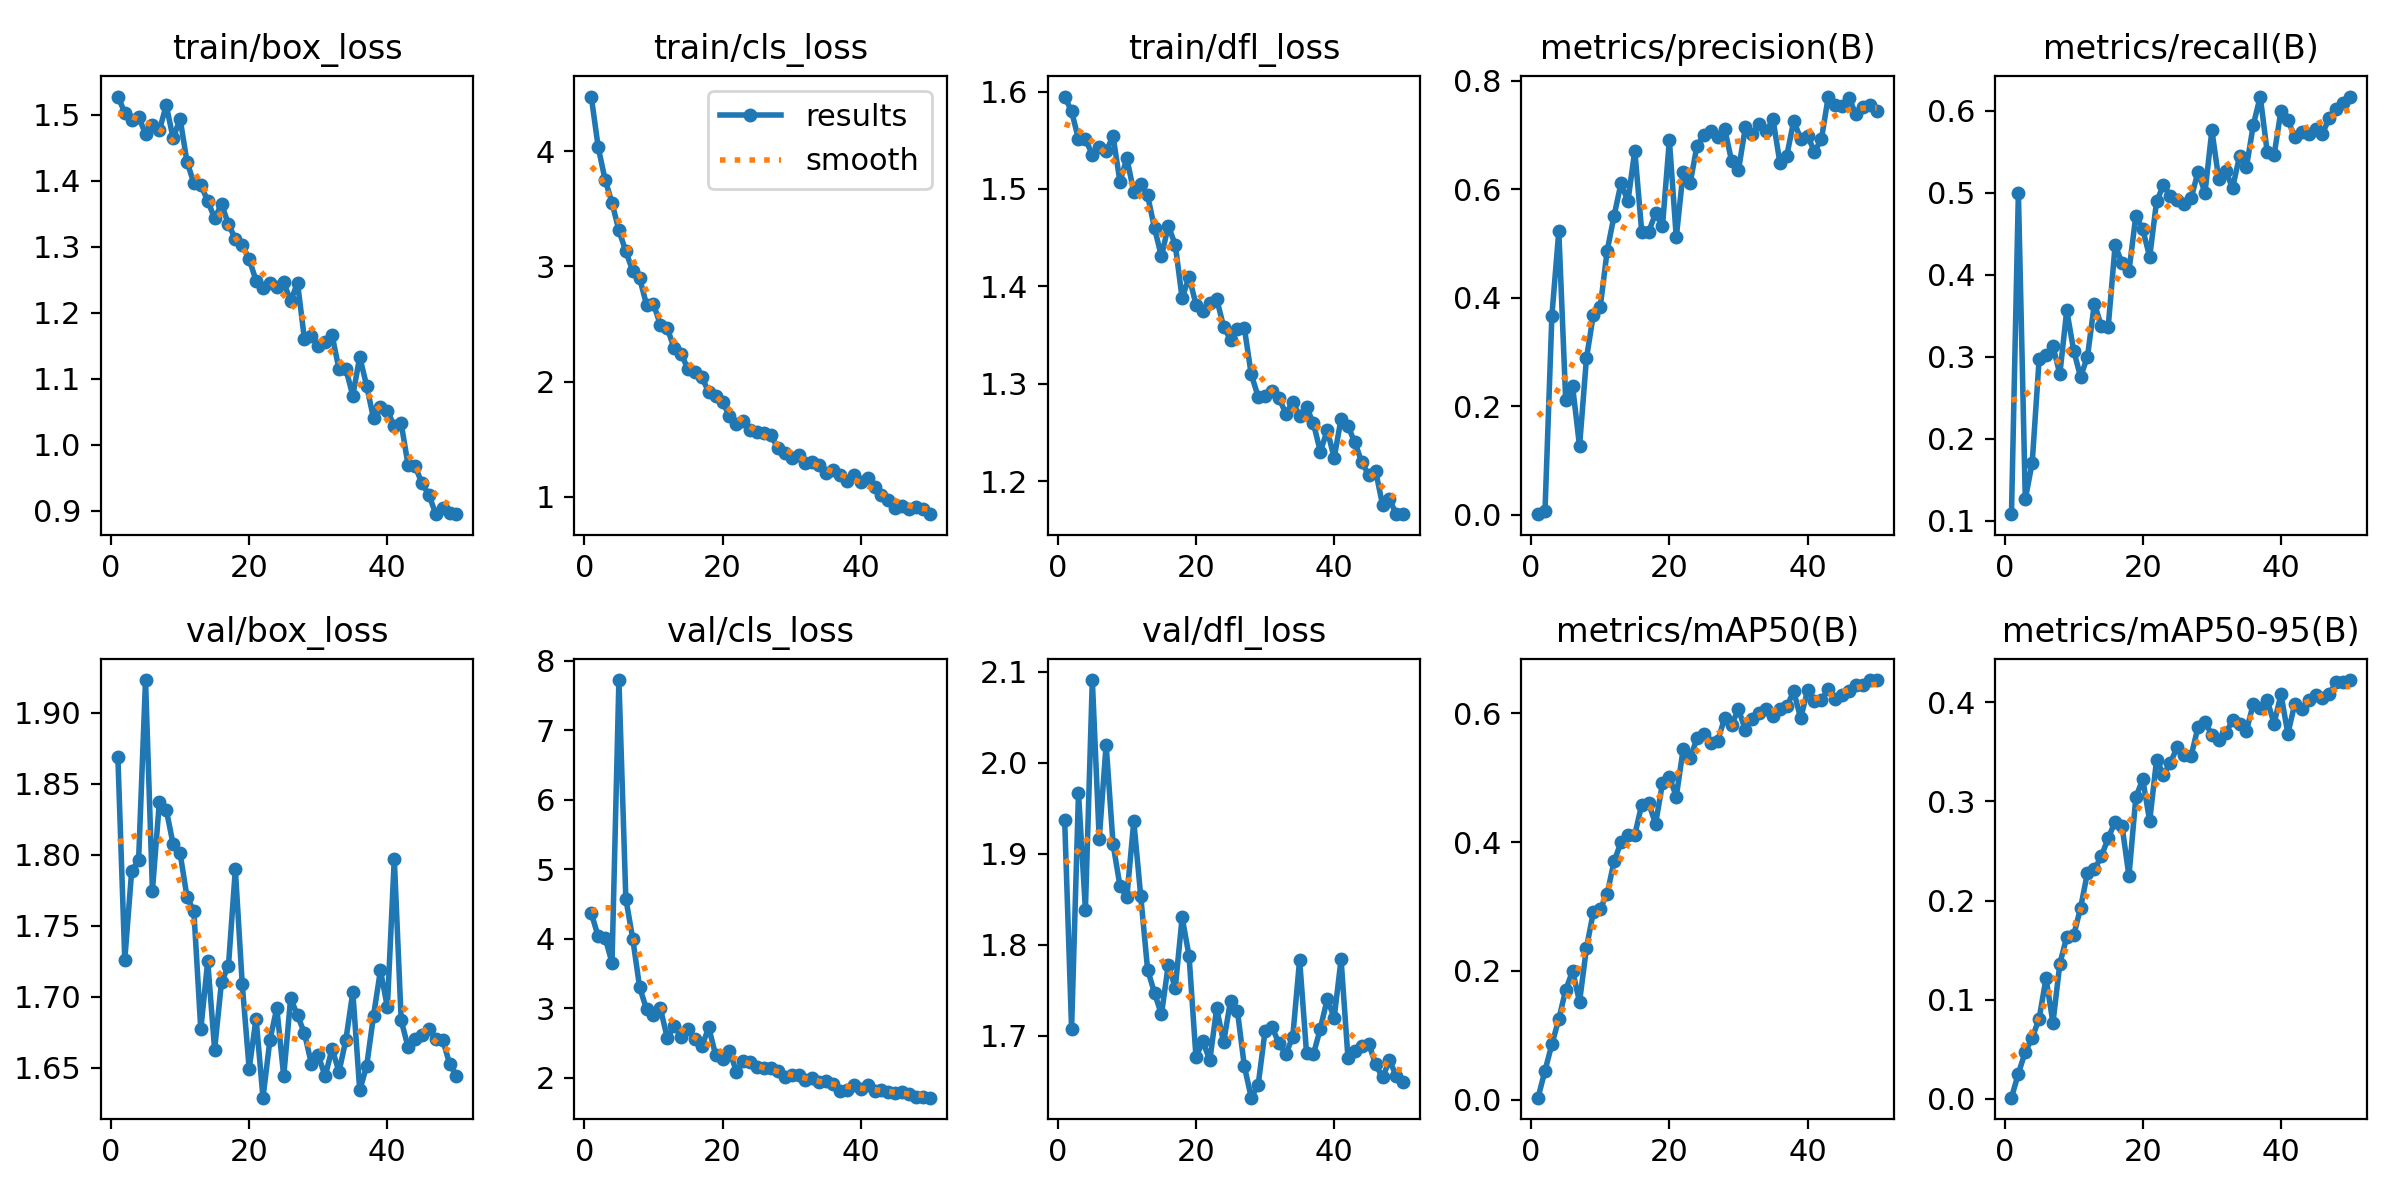



🎯 Matriz de confusión:


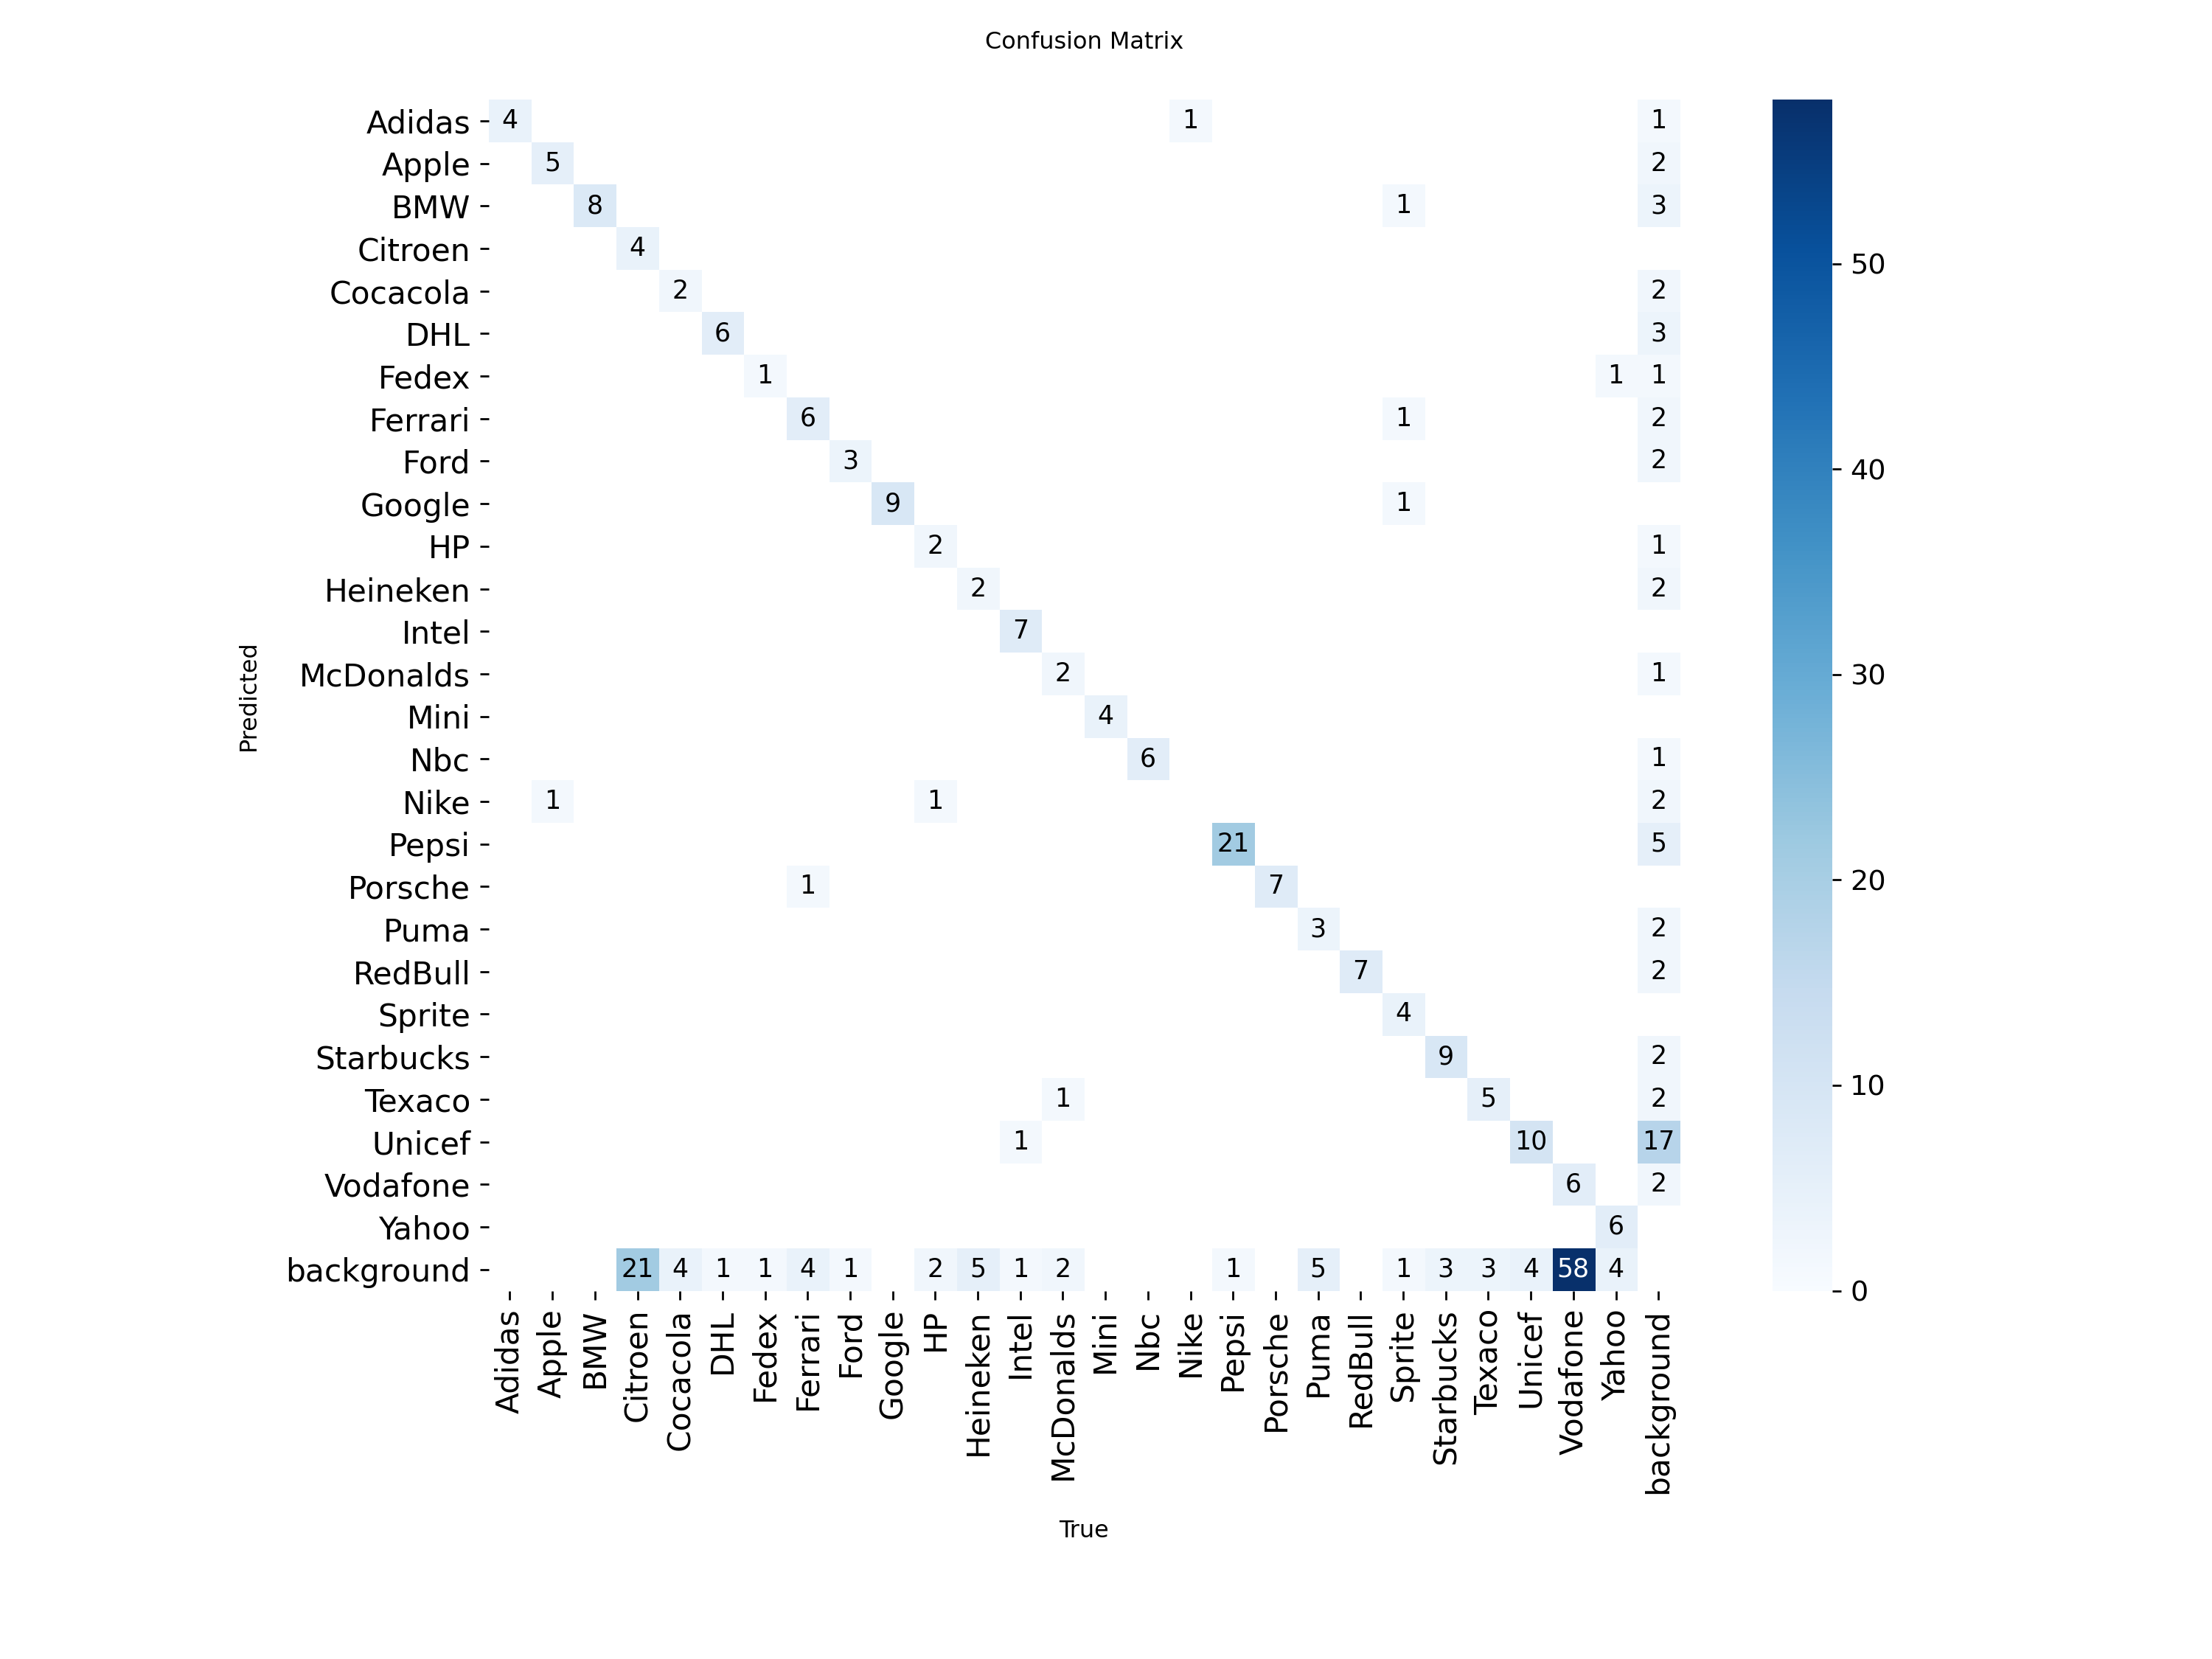



📊 Distribución de clases:


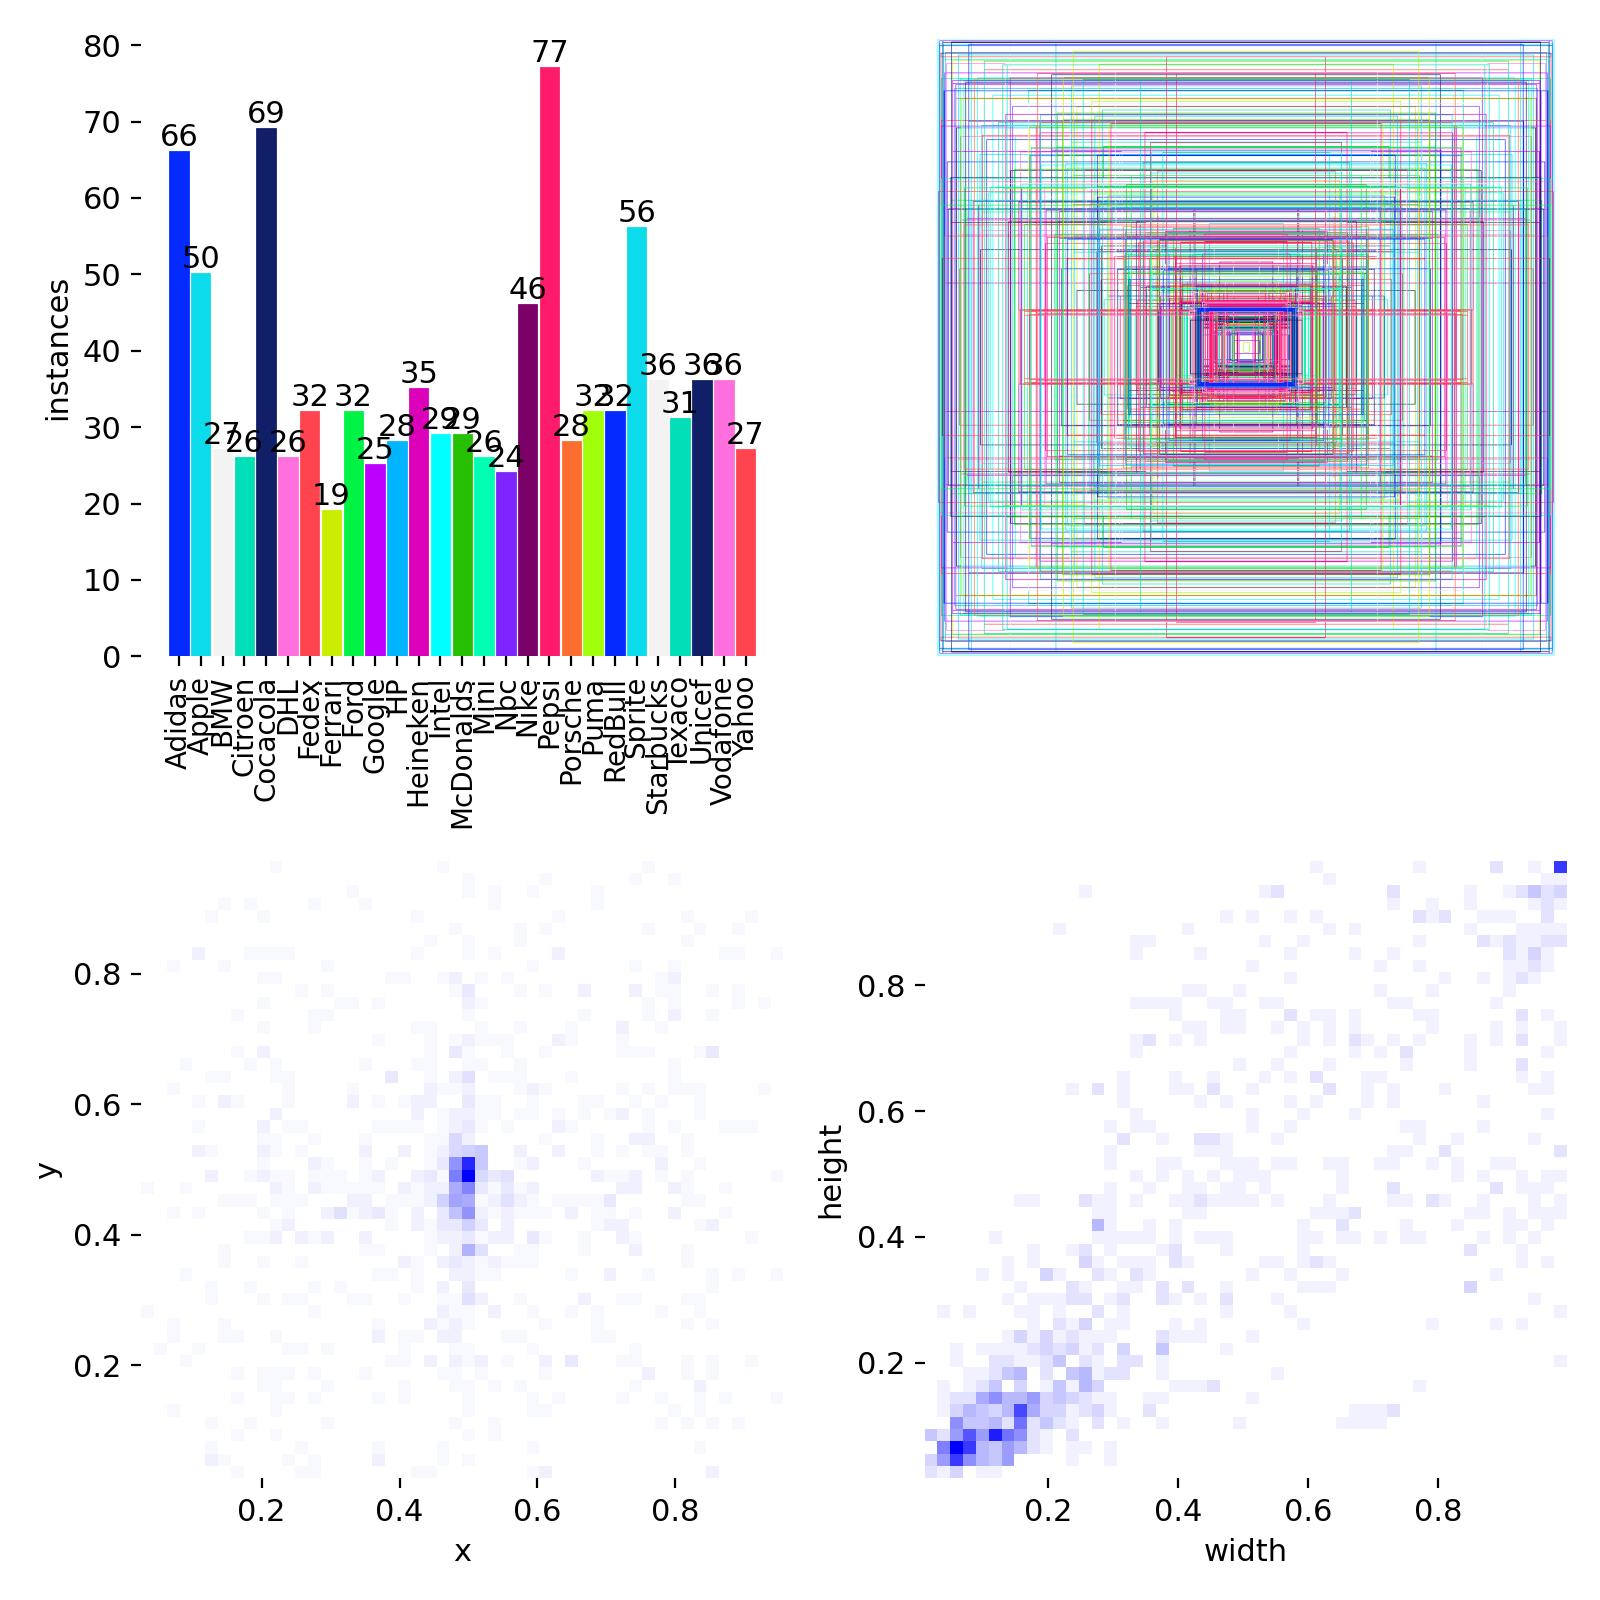



🖼️ Predicciones en batch de validación:


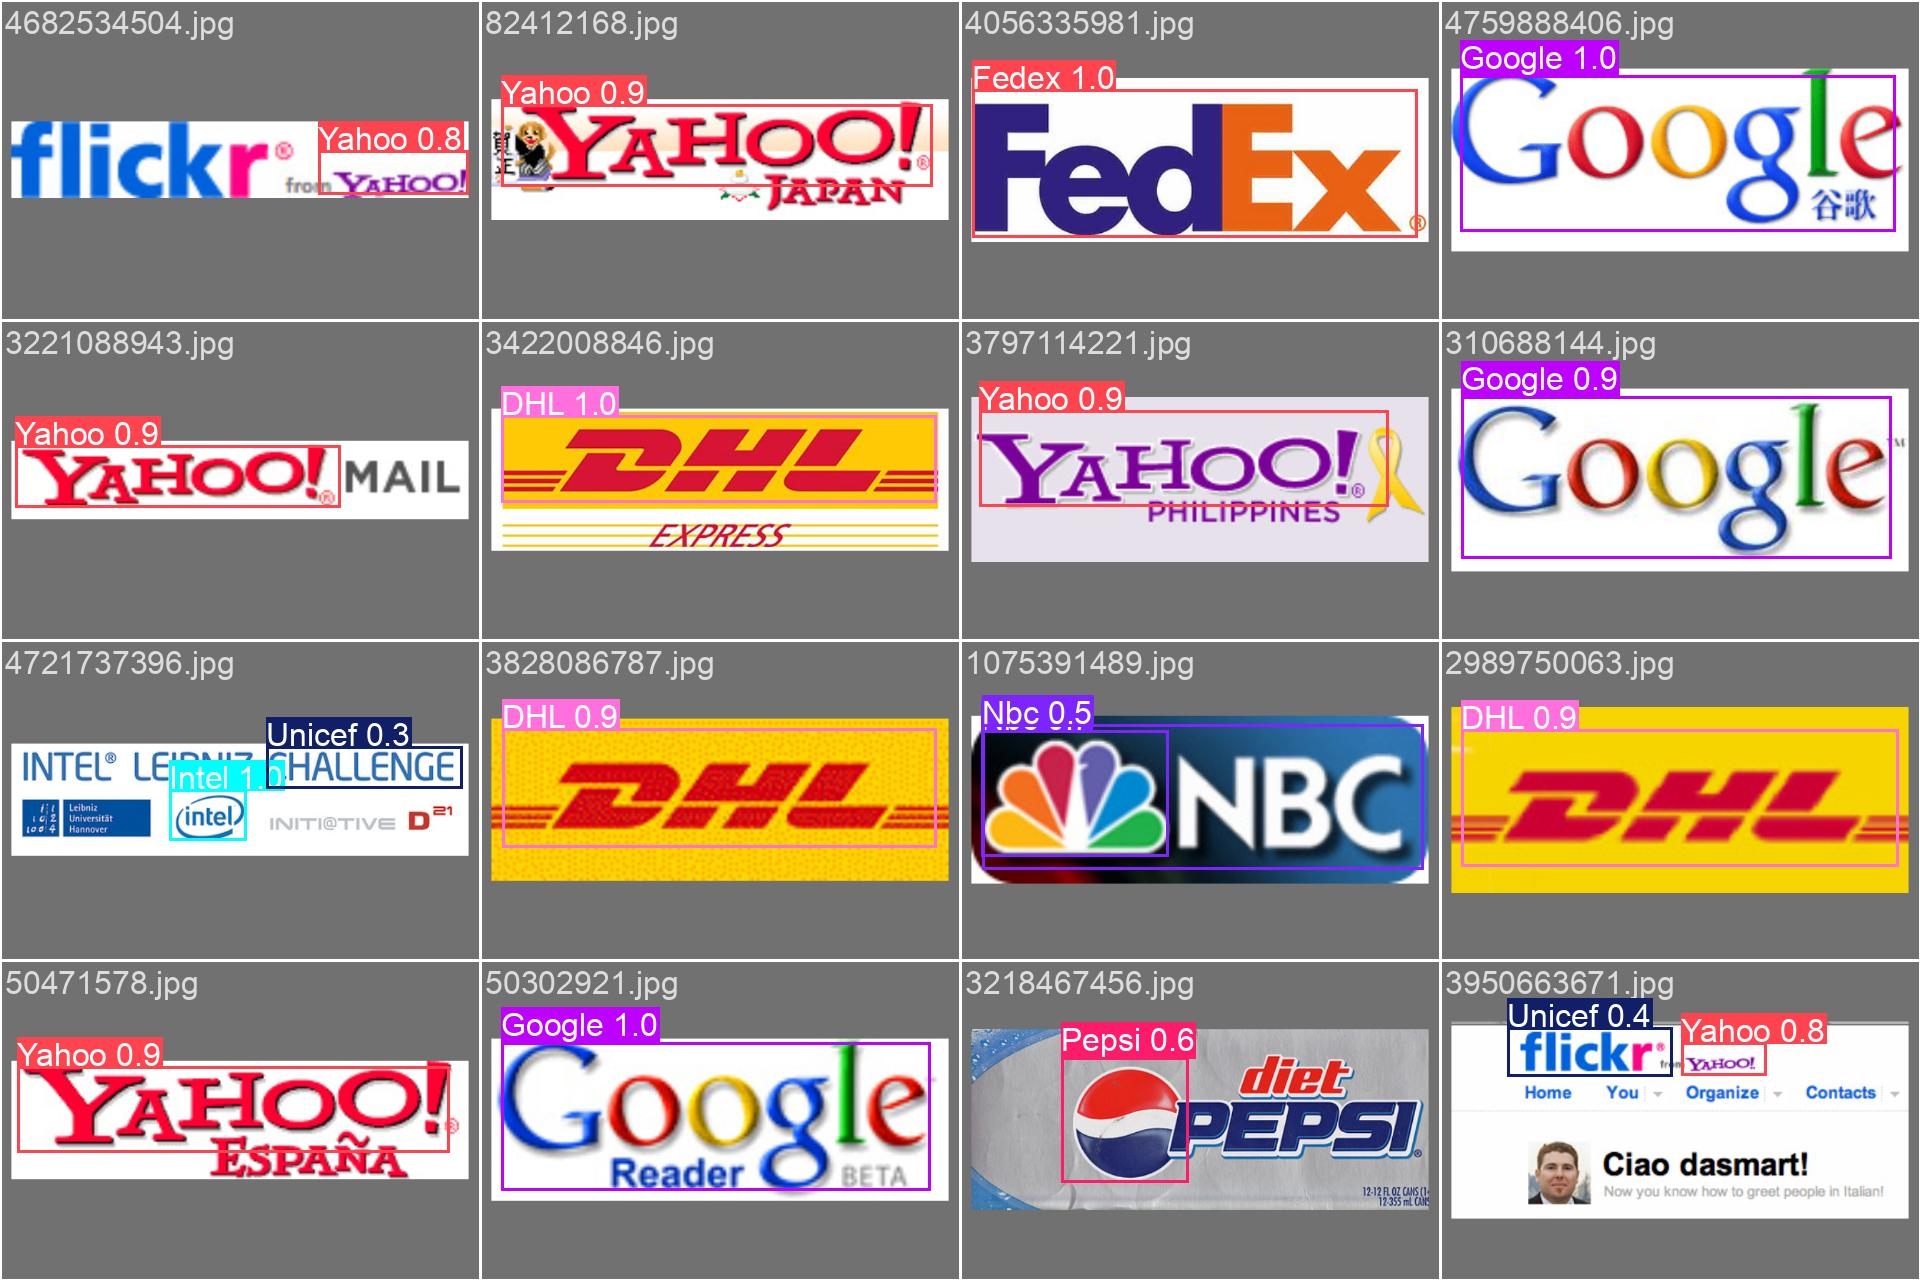

In [54]:
from IPython.display import Image, display
import os

# Directorio de resultados (actualizado para el nuevo nombre de experimento)
results_dir = '/content/runs/detect/runs/detect/logos_flickr_dataset4' # Corrected path

print("📊 RESULTADOS DEL ENTRENAMIENTO\n")

# 1. Curvas de entrenamiento (pérdida, precisión, recall, mAP)
if os.path.exists(f'{results_dir}/results.png'):
    print("📈 Curvas de entrenamiento:")
    display(Image(filename=f'{results_dir}/results.png', width=800))
else:
    print("⚠️ results.png no encontrado")

print("\n" + "="*60 + "\n")

# 2. Matriz de confusión
if os.path.exists(f'{results_dir}/confusion_matrix.png'):
    print("🎯 Matriz de confusión:")
    display(Image(filename=f'{results_dir}/confusion_matrix.png', width=600))
else:
    print("⚠️ confusion_matrix.png no encontrado")

print("\n" + "="*60 + "\n")

# 3. Distribución de labels
if os.path.exists(f'{results_dir}/labels.jpg'):
    print("📊 Distribución de clases:")
    display(Image(filename=f'{results_dir}/labels.jpg', width=600))

print("\n" + "="*60 + "\n")

# 4. Ejemplos de predicciones en validación
if os.path.exists(f'{results_dir}/val_batch0_pred.jpg'):
    print("🖼️ Predicciones en batch de validación:")
    display(Image(filename=f'{results_dir}/val_batch0_pred.jpg', width=800))

# Task
Validate the YOLOv11 model and display the final metrics including mAP50, mAP50-95, precision, recall, and per-class mAP, using the trained model.

## Correct Visualization Path

### Subtask:
Modify the `results_dir` variable in cell `9d7bc3a8` to point to the correct output directory of the last training run.


## Validate Model

### Subtask:
Validate the trained model and display its performance metrics.

**Reasoning**:
The next step is to validate the trained model and display its performance metrics using the `model.val()` method, which is the standard procedure after training a YOLO model.



In [55]:
# Validar el modelo en el conjunto de validación
print("🧪 Ejecutando validación final...\n")
metrics = model.val()

# Mostrar métricas principales
print("\n" + "="*60)
print("📊 MÉTRICAS FINALES DEL MODELO")
print("="*60)
print(f"mAP50 (IoU=0.5):           {metrics.box.map50:.3f}")
print(f"mAP50-95 (IoU=0.5:0.95):   {metrics.box.map:.3f}")
print(f"Precisión:                 {metrics.box.mp:.3f}")
print(f"Recall:                    {metrics.box.mr:.3f}")
print("="*60)

# Métricas por clase
print("\n📋 Métricas por clase:")
# Aseguramos que class_names se alinee con las clases de flickr_logos_27_dataset
# Por defecto, este dataset tiene 27 clases de logos, pero podemos usar el del modelo si no se detectan clases específicas.
# Si 'metrics.names' contiene los nombres de las clases, es preferible usarlo.
# De lo contrario, usaremos un marcador de posición o se solicitará al usuario si es necesario.
if hasattr(metrics, 'names') and metrics.names:
    current_class_names = [metrics.names[i] for i in sorted(metrics.names.keys())]
else:
    current_class_names = [f'clase_{i}' for i in range(len(metrics.box.maps))] # Fallback

for i, name in enumerate(current_class_names):
    if i < len(metrics.box.maps):
        print(f"  {name:12s} - mAP50: {metrics.box.maps[i]:.3f}")
    else:
        print(f"  {name:12s} - No mAP50 disponible")

🧪 Ejecutando validación final...

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 101 layers, 2,587,417 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1167.7±660.1 MB/s, size: 130.7 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 162 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 162/162 37.7Mit/s 0.0s
val: /content/yolo_dataset/images/val/1111800334.jpg: 2 duplicate labels removed
val: /content/yolo_dataset/images/val/1352999361.jpg: 3 duplicate labels removed
val: /content/yolo_dataset/images/val/1402065041.jpg: 3 duplicate labels removed
val: /content/yolo_dataset/images/val/1508285598.jpg: 4 duplicate labels removed
val: /content/yolo_dataset/images/val/162002009.jpg: 2 duplicate labels removed
val: /content/yolo_dataset/images/val/217288720.jpg: 5 duplicate labels removed
val: /content/yolo_dataset/images/val/2175812747.jpg: 3 duplicate labels removed
val: /content/yol

**Reasoning**:
The model has been validated and its metrics are displayed. The next step, as per the overall task, is to save the trained model and its results to Google Drive.



In [56]:
# Comprimir resultados completos
print("📦 Comprimiendo modelo y resultados...")
!zip -r /content/yolo11_flickr_trained_complete.zip /content/runs/detect/runs/detect/logos_flickr_dataset4/ # Nombre de archivo y ruta actualizados

# Guardar en Google Drive
!cp /content/yolo11_flickr_trained_complete.zip /content/drive/MyDrive/

# También copiar solo el mejor modelo
!cp /content/runs/detect/runs/detect/logos_flickr_dataset4/weights/best.pt /content/drive/MyDrive/yolo11_flickr_best.pt # Nombre de archivo y ruta actualizados

print("\n✅ Archivos guardados en Google Drive:")
print("   📁 yolo11_flickr_trained_complete.zip (todos los resultados del dataset Flickr)")
print("   🎯 yolo11_flickr_best.pt (mejor modelo del dataset Flickr)")
print("\n💡 Puedes descargar estos archivos desde Google Drive")

📦 Comprimiendo modelo y resultados...
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/ (stored 0%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/weights/ (stored 0%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/weights/last.pt (deflated 10%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/weights/best.pt (deflated 10%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/train_batch1641.jpg (deflated 13%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/val_batch2_labels.jpg (deflated 9%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/train_batch1.jpg (deflated 8%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/val_batch0_labels.jpg (deflated 29%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/train_batch0.jpg (deflated 5%)
  adding: content/runs/detect/runs/detect/logos_flickr_dataset4/results.csv (deflated 59%)
  adding: content/runs/detect

## Test Model

### Subtask:
Test the trained model with a sample image from the new validation set.


**Reasoning**:
I need to provide the code to test the trained model with a sample image from the validation set. This involves updating the paths for the best model and the validation images as specified in the instructions. I will use the code from cell `e04bc6c6` as a base and modify the paths accordingly.



🖼️ Probando modelo con imagen de prueba: /content/yolo_dataset/images/val/427097328.jpg


image 1/1 /content/yolo_dataset/images/val/427097328.jpg: 448x640 1 Mini, 161.1ms
Speed: 8.3ms preprocess, 161.1ms inference, 13.1ms postprocess per image at shape (1, 3, 448, 640)


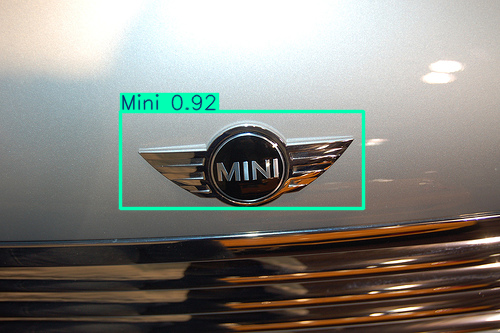


✅ Detectados 1 logos:
  - Mini: 91.98% confianza


In [57]:
from ultralytics import YOLO
import time
from IPython.display import Image, display
import glob
from PIL import Image # Added this import

# Cargar el mejor modelo entrenado del nuevo experimento
best_model = YOLO('/content/runs/detect/runs/detect/logos_flickr_dataset4/weights/best.pt') # Ruta actualizada

# Probar con una imagen de validación del nuevo dataset
val_images = glob.glob('/content/yolo_dataset/images/val/*.jpg')
if val_images:
    test_image = val_images[0] # Use the first image found in the validation set
else:
    test_image = None
    print("⚠️ No se encontraron imágenes en el conjunto de validación del nuevo dataset para probar.")


if test_image:
    print(f"🖼️ Probando modelo con imagen de prueba: {test_image}\n")

    # Hacer predicción
    results = best_model(test_image)

    # Mostrar imagen con detecciones
    for r in results:
        im_array = r.plot()  # Plot con bounding boxes
        im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
        display(im)

        # Mostrar detecciones
        if len(r.boxes) > 0:
            print(f"\n✅ Detectados {len(r.boxes)} logos:")
            # Obtenemos los nombres de las clases del modelo para mostrarlos correctamente
            class_names_for_test = best_model.names if hasattr(best_model, 'names') else [f'clase_{i}' for i in range(len(best_model.model.names))]
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                print(f"  - {class_names_for_test[cls_id]}: {conf:.2%} confianza")
        else:
            print("\n⚠️ No se detectaron logos en esta imagen")

## Final Task

### Subtask:
Summarize the successful training and availability of the model.


## Summary:

### Q&A
The YOLOv11 model was successfully validated, and its performance metrics were displayed. The model demonstrated overall mAP50 of 0.651, mAP50-95 of 0.422, Precision of 0.741, and Recall of 0.617. The training was successful, and the complete results and best model checkpoint have been made available in Google Drive.

### Data Analysis Key Findings
*   The YOLOv11 model achieved an overall mAP50 (IoU=0.5) of 0.651 and mAP50-95 (IoU=0.5:0.95) of 0.422.
*   The model's precision was 0.741, and its recall was 0.617.
*   Per-class mAP50 varied significantly, with examples such as Adidas at 0.705, Apple at 0.279, BMW at 0.446, Pepsi at 0.525, and Nike at 0.004.
*   The complete training results were compressed into `yolo11_flickr_trained_complete.zip` and the best model checkpoint (`yolo11_flickr_best.pt`) was saved to Google Drive.
*   A test on a sample validation image (`/content/yolo_dataset/images/val/427097328.jpg`) successfully detected a "Mini" logo with 91.98% confidence.

### Insights or Next Steps
*   Further investigation into classes with low mAP50 (e.g., Nike, Apple) could help identify issues such as insufficient training data, poor annotation quality, or challenging characteristics, guiding targeted improvements.
*   The trained model and its comprehensive results are now readily available for deployment or further experimentation, stored securely in Google Drive.
